In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines
import os
import matplotlib.patches as mpatches
import sys
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import Draw
from rdkit import Chem
from rdkit.Chem.rdmolfiles import MolToSmarts, MolFromSmiles, MolFromSmarts


from utils.lipinskiness import lipinskiness

In [23]:
ar_tm1 = {}
for n in [1,2]:
    key = f'f{n}'
    ar_tm1[key] = pd.read_csv(f'opt/AR_TM1_f{n}.csv', sep="\s+", header=None)
    ar_tm1[key].columns = ['time','smiles','druglikeness_sc','binding_sc']
    ar_tm1[key].index = range(1,len(ar_tm1[key])+1)
for key, value in ar_tm1.items():
    sample = ar_tm1[key].sample(n=500,random_state=28).reset_index(drop=True)
    ar_tm1[key] = sample

In [24]:
ar_tm1['f1'].sort_values(by='binding_sc')

,time,smiles,druglikeness_sc,binding_sc
268,1.743815e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C2=NNC(=O)N2C...,1.505882,-7.7
365,1.743836e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(CC=C(F)F)=NNC1=O,1.714286,-7.6
109,1.743691e+09,C=CC=C(F)CC(O)(O)C1=NNC(=O)N1C1C2=CC(C)C(O)=C2...,1.521739,-7.6
164,1.743746e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C(=S)CN)=NNC1=O,1.505882,-7.6
348,1.743687e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C2=NNC(=O)N2C...,1.697674,-7.5
...,...,...,...,...
270,1.743709e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C(S)ON=O)=NNC1=O,1.731707,14.7
392,1.743833e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C2=NNC(=O)N2C...,1.505882,15.2
90,1.743784e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(CC2([SH](=O)=...,1.840000,16.4
27,1.743835e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2N1C(C2=NNC(=O)N2C...,1.505882,17.8


In [25]:
filtered_ar_tm1_f2 = ar_tm1['f2'][ar_tm1['f2']['binding_sc'] < -7.7]

In [26]:
len(filtered_ar_tm1_f2)

16

In [27]:
filtered_ar_tm1_f2.sort_values(by='binding_sc')


,time,smiles,druglikeness_sc,binding_sc
74,1.743740e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C(N)(Cl)NOC(F)=CN,1.307692,-8.5
132,1.743824e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2CC1(N)N=C(C(F)(F)...,1.666667,-8.2
434,1.743787e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C(Cl)=NONC(=O)C1C...,1.615385,-8.2
193,1.743702e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C1(NSCC(F)(F)F)SC...,1.279070,-8.0
485,1.743734e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C(Cl)=CN=C(F)Cl,1.685714,-8.0
299,1.743758e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C(Cl)=CN=C(F)F,1.685714,-7.9
305,1.743782e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C(Cl)=NONS(=O)(=O...,1.750000,-7.9
345,1.743772e+09,C=CC=C(F)ON=C(Cl)C1C2=CC(C)C(O)=C2C(C)C(Cl)C1F,1.514286,-7.9
36,1.743733e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2C=CNNCCC(O)(F)F,1.391304,-7.8
81,1.743823e+09,CC1C=C2C(=C1O)C(C)C(Cl)C(F)C2CC1N=CNNC1=CO,1.545455,-7.8


dict_values([2.0, 2.0, 2.0])
Highest Tanimoto similarity score (AR): 0.644


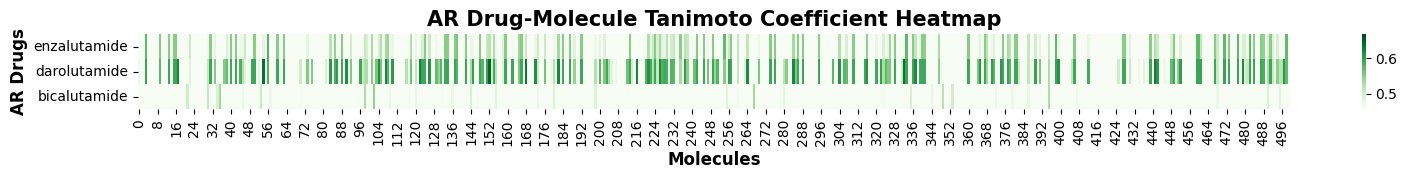

Average Tanimoto score for AR-targeting molecules: 0.457
Std Dev: 0.114


In [28]:
ar_smiles = ar_tm1['f2'].smiles.to_list()

ar_drug_name = ['enzalutamide', 'darolutamide', 'bicalutamide']

ar_drug_dir = {'enzalutamide':'CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=CC(=C(C=C3)C#N)C(F)(F)F)C', 
               'darolutamide': 'CC(CN1C=CC(=N1)C2=CC(=C(C=C2)C#N)Cl)NC(=O)C3=NNC(=C3)C(C)O', 
               'bicalutamide': 'CC(CS(=O)(=O)C1=CC=C(C=C1)F)(C(=O)NC2=CC(=C(C=C2)C#N)C(F)(F)F)O'}

ar_drug_dock = {'enzalutamide': -6.8, 
               'darolutamide': -8.5, 
               'bicalutamide': -9.8}

ar_drug_lip = {}
for key, smiles in ar_drug_dir.items():
    lip_sc = lipinskiness(smiles)
    ar_drug_lip[key] = lip_sc
print(ar_drug_lip.values())

# Convert SMILES to molecules and fingerprints
ar_drugs = [Chem.MolFromSmiles(smile) for smile in ar_drug_dir.values()]
ar_drug_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_drugs]

ar_mols = [Chem.MolFromSmiles(smile) for smile in ar_smiles]
ar_mol_fps = [MACCSkeys.GenMACCSKeys(mol) for mol in ar_mols]

# Calculate similarity matrix
similarity_matrix_ar = np.zeros((len(ar_drugs), len(ar_mols)))
for i in range(len(ar_drugs)):
    for j in range(len(ar_mols)):
        score = DataStructs.TanimotoSimilarity(ar_drug_fps[i], ar_mol_fps[j])
        similarity_matrix_ar[i, j] = score

# Max similarity score
max_score_ar = np.max(similarity_matrix_ar)
print(f"Highest Tanimoto similarity score (AR): {max_score_ar:.3f}")

# Plot heatmap for AR
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix_ar, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=[f'{key}' for key in ar_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('AR Drugs', fontsize=12, fontweight='bold')
plt.title('AR Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()

# Compute maximum similarity scores for each molecule
ar_tani_score = []
for i in range(len(ar_mols)):
    score = 0
    for j in range(len(ar_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(ar_drug_fps[j], ar_mol_fps[i])
        if tani_score > score:
            score = tani_score
    ar_tani_score.append(score)
ar_tani_score = np.array(ar_tani_score)
print(f"Average Tanimoto score for AR-targeting molecules: {ar_tani_score.mean():.3f}")
print(f"Std Dev: {ar_tani_score.std():.3f}")

In [29]:
her2_tm3 = {}
for n in [1,'2-4']:
    key = f'f{n}'
    her2_tm3[key] = pd.read_csv(f'opt/HER2_TM3_f{n}.csv', sep="\s+", header=None)
    her2_tm3[key].columns = ['time','smiles','druglikeness_sc','binding_sc']
    her2_tm3[key].index = range(1,len(her2_tm3[key])+1)

f1_sample = her2_tm3['f1'].sample(n=500,random_state=28).reset_index(drop=True)
f2to4_sample = her2_tm3['f2-4'].sample(n=1500,random_state=28).reset_index(drop=True)
her2_tm3['f1'] = f1_sample
her2_tm3['f2-4']=f2to4_sample

In [30]:
her2_tm3['f1'][her2_tm3['f1']['binding_sc']<-8.4]

,time,smiles,druglikeness_sc,binding_sc
0,1.748513e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(SCCl...,0.761049,-8.8
1,1.748555e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(=O)S...,0.983821,-9.2
2,1.748522e+09,C=C(O)C(CC)=C(NC1=CC2C(C(NC(F)(F)F)O1)C(S(=O)(...,1.169014,-8.6
3,1.748520e+09,CC1CCC=C1C(NC1=CC2C(C(NC(F)(F)F)O1)C(S(=O)(=O)...,1.274008,-9.3
4,1.748563e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(=O)S...,1.135450,-8.8
...,...,...,...,...
495,1.748485e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(C)(F...,1.271429,-9.1
496,1.748468e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(F)OC...,1.354973,-9.1
497,1.748525e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,1.227135,-9.3
498,1.748453e+09,CC1C=C(C(C)(N)CNC2=CC3C(C(NC(F)(F)F)O2)C(S(=O)...,1.147619,-8.9


In [31]:
her2_tm1 = {}
for n in [1,2,3]:
    key = f'f{n}'
    her2_tm1[key] = pd.read_csv(f'opt/HER2_TM1_f{n}.csv', sep="\s+", header=None)
    her2_tm1[key].columns = ['time','smiles','druglikeness_sc','binding_sc']
    her2_tm1[key].index = range(1,len(her2_tm1[key])+1)
    print(len(her2_tm1[key]))


2351
1427
522


In [32]:
for frag, df in her2_tm1.items():
    filtered = df[df['binding_sc']< -8.6]
    print(frag,len(filtered))

f1 581
f2 165
f3 32


In [33]:
her2_tm1['f1'][her2_tm1['f1']['binding_sc']<-8.6].sort_values(by='binding_sc',ascending=True)

,time,smiles,druglikeness_sc,binding_sc
264,1.743710e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,0.750491,-9.9
261,1.743710e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.207453,-9.9
208,1.750957e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.106030,-9.8
210,1.743706e+09,CC(NOC1=NN=NN1)NC1=CC2N(C=C1CCCCC1=CNCCC1)C(C)...,1.135313,-9.8
1686,1.748488e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.035313,-9.7
...,...,...,...,...
661,1.748449e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.211278,-8.7
1751,1.751030e+09,C=CCN1CC=NSC1CNC1=CC2N(C=C1CCCCC1=CNCCC1)C(C)C...,1.202260,-8.7
1762,1.748491e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.487108,-8.7
730,1.750951e+09,CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C...,1.380952,-8.7


In [34]:
her2_tm1['f1'][her2_tm1['f1']['binding_sc']<-8.6].sort_values(by='binding_sc',ascending=True).smiles.to_list()[:5]

['CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C(F)(F)F)C2C=C(NCNC3C=NC(F)C4CCCCC34)C(CCCCC3=CNCCC3)=CN12',
 'CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C(F)(F)F)C2C=C(NC(O)C3CC(=O)NCN3)C(CCCCC3=CNCCC3)=CN12',
 'CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C(F)(F)F)C2C=C(NC(SS(=O)S(=O)(=O)Cl)S(=O)(=O)Cl)C(CCCCC3=CNCCC3)=CN12',
 'CC(NOC1=NN=NN1)NC1=CC2N(C=C1CCCCC1=CNCCC1)C(C)C(Cl)C2(C1C(C(F)(F)F)CCCS1(=O)=O)S(=O)(=O)C(F)(F)F',
 'CC1C(Cl)C(C2C(C(F)(F)F)CCCS2(=O)=O)(S(=O)(=O)C(F)(F)F)C2C=C(NC(NO)C3=NN=NNC3)C(CCCCC3=CNCCC3)=CN12']

In [35]:
her2_tm1['f2'][her2_tm1['f2']['binding_sc']<-8.6].sort_values(by='binding_sc',ascending=True)

,time,smiles,druglikeness_sc,binding_sc
963,1.751014e+09,CC1C(Cl)C(C2C(CSC3=CNC(=O)NC3)CCCS2(=O)=O)(S(=...,1.170987,-9.5
224,1.743707e+09,CCC(=O)ONC(CC)CC1CCCS(=O)(=O)C1C1(S(=O)(=O)C(F...,0.857143,-9.5
1176,1.748526e+09,CC1C(Cl)C(C2C(C(N=O)NC3=CC(Cl)CC3)CCCS2(=O)=O)...,1.029622,-9.4
1060,1.751023e+09,CC1C(Cl)C(C2C(CSC3CCC4=C(O3)C(C)(C)CC=C4)CCCS2...,0.618012,-9.3
890,1.748504e+09,CC1C(Cl)C(C2C(CNNC3NCC=C3F)CCCS2(=O)=O)(S(=O)(...,0.770563,-9.3
...,...,...,...,...
643,1.748487e+09,CCSCC(C)NCCNNCC1CCCS(=O)(=O)C1C1(S(=O)(=O)C(F)...,0.316967,-8.7
1149,1.743777e+09,CC1C(Cl)C(C2C(C(N)CSC(=O)NN=N)CCCS2(=O)=O)(S(=...,1.048120,-8.7
1150,1.743777e+09,CC1C(Cl)C(C2C(C(CSC3CCNC3)OC(O)NCCS)CCCS2(=O)=...,0.262844,-8.7
367,1.743718e+09,CC1C(Cl)C(C2C(CCCC3CC(Cl)CCN3)CCCS2(=O)=O)(S(=...,0.879073,-8.7


In [36]:
her2_tm1['f3'][her2_tm1['f3']['binding_sc']<-8.6].sort_values(by='binding_sc',ascending=True)

,time,smiles,druglikeness_sc,binding_sc
94,1.750946e+09,C=CNCCCSCCC(O)C1(S(=O)(=O)C(F)(F)F)C(Cl)C(C)N2...,1.077019,-9.4
65,1.748440e+09,CCC1NN=CC1OC(C)C1(S(=O)(=O)C(F)(F)F)C(Cl)C(C)N...,1.151948,-9.2
66,1.750943e+09,CC(=O)NCC(C)(O)C1(S(=O)(=O)C(F)(F)F)C(Cl)C(C)N...,1.248021,-9.2
407,1.748465e+09,CC1C(Cl)C(C(O)(S)C2CCC3NCCC(F)C3N2)(S(=O)(=O)C...,0.558647,-9.2
522,1.750975e+09,CC1C(Cl)C(C(F)NC=CC(=O)C2CNCCN2)(S(=O)(=O)C(F)...,0.961538,-9.1
31,1.748437e+09,CC1C(Cl)C(C(C=CC=CC=CS)CCCl)(S(=O)(=O)C(F)(F)F...,1.247619,-9.0
59,1.750942e+09,CC1C(Cl)C(C2(C3SNSN3N)CCNC2)(S(=O)(=O)C(F)(F)F...,1.170330,-9.0
439,1.748467e+09,CC1C(Cl)C(C(O)(S)C2CCC3CCNN=C3N2)(S(=O)(=O)C(F...,0.577019,-9.0
496,1.748470e+09,CC=CCNC(=O)C(F)C1(S(=O)(=O)C(F)(F)F)C(Cl)C(C)N...,1.320310,-9.0
119,1.748445e+09,CNCC=C(F)NNC(C)C1(S(=O)(=O)C(F)(F)F)C(Cl)C(C)N...,0.951948,-9.0


In [37]:
her2_tm3['f2-4'][her2_tm3['f2-4']['binding_sc']<-8.4]

,time,smiles,druglikeness_sc,binding_sc
16,1.743818e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NCCCO)=...,1.153846,-9.3
20,1.743788e+09,CCC(C(N)=O)C(Cl)N1C(C)C(S(=O)(=O)S(=O)Cl)C2C(N...,1.491803,-9.0
22,1.748536e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,0.546923,-9.2
23,1.750980e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(C(=S)NC3=CCC=CC3)OC(...,1.369103,-8.7
24,1.748530e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,0.938971,-9.6
...,...,...,...,...
1470,1.748579e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(N)(O...,0.968571,-9.0
1474,1.750955e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(C(N)=CCC3NCC4NCCC=C4...,0.123403,-8.6
1480,1.748481e+09,CC1CCCC(C(C)(F)NC2=CC3C(C(NC(F)(F)F)O2)C(S(=O)...,1.208867,-9.2
1481,1.748487e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NCN(CC(...,0.429568,-8.9


In [38]:
her2_tm3['f2-4'].sort_values(by='binding_sc')

,time,smiles,druglikeness_sc,binding_sc
172,1.751068e+09,O=C(NC=CNC(=O)NC1CC2CCCCC2(F)C(F)(F)C1)NC1CC2C...,1.257143,-10.2
758,1.748523e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,0.990037,-10.1
425,1.748526e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,1.406872,-10.0
1464,1.748501e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC(N)=N...,0.945865,-9.9
678,1.748534e+09,CC1C(S(=O)(=O)S(=O)Cl)C2C(NC(F)(F)F)OC(NC3(S(=...,0.510836,-9.9
...,...,...,...,...
959,1.750976e+09,C(=CSCCSCOC1N=NCCS1)SCCSCOC1N=NCCS1,1.160000,-4.8
858,1.750974e+09,COCSCCSC(ON=O)=C(ON=O)SCCSCOC,1.250000,-4.8
1419,1.751023e+09,O=NOCCC=CCCON=O,1.551515,-4.6
311,1.751055e+09,NN=NN=NC=NCCNC=CNCCN=CN=NN=NN,2.000000,-4.5


In [39]:
smiles = her2_tm3['f2-4'].sort_values(by='binding_sc').smiles.to_list()[:3]

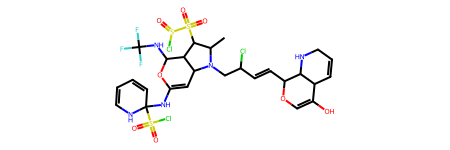

In [40]:
MolFromSmiles(smiles[2])

dict_values([2.0, 2.0, 1.8])
Highest tanimoto similarity score: 0.663
Average Tanimoto score for HER2-targeting molecules: 0.5825702151393874, 
std: 0.027


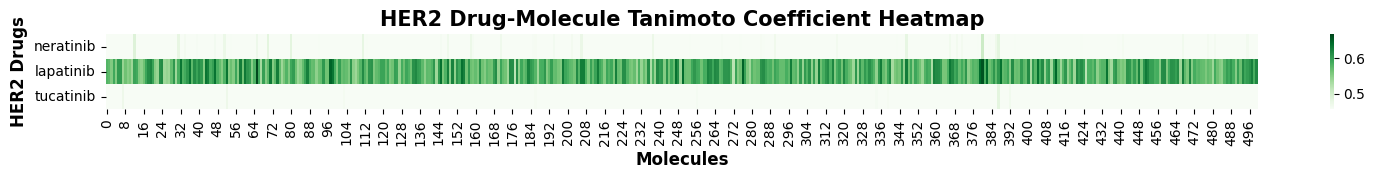

In [41]:
her2_smiles = her2_tm3['f1'].smiles.to_list()
her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_name= her2_drug_dir.keys()
her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}


her2_drug_lip = {}
for key, values in her2_drug_dir.items():
    lip_sc = lipinskiness(values)
    her2_drug_lip[key] = lip_sc
print(her2_drug_lip.values())


her2_drugs = [Chem.MolFromSmiles(drug) for drug in her2_drug_dir.values()]
her2_drug_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_drugs]
her2_mols = [Chem.MolFromSmiles(smile) for smile in her2_smiles]
her2_mol_fps = [ MACCSkeys.GenMACCSKeys(x) for x in her2_mols]

similarity_matrix = np.zeros((len(her2_drugs), len(her2_mols)))

# Calculate similarity scores
for i in range(len(her2_drugs)):
    for j in range(len(her2_mols)):
        score = DataStructs.TanimotoSimilarity(her2_drug_fps[i], her2_mol_fps[j])
        similarity_matrix[i, j] = score
max_score = np.max(similarity_matrix)
print(f"Highest tanimoto similarity score: {max_score:.3f}")


her2_tani_score = []
for i in range(len(her2_mols)):
    score = 0
    for j in range(len(her2_drugs)):
        tani_score = DataStructs.TanimotoSimilarity(her2_drug_fps[j], her2_mol_fps[i])
        if tani_score > score:
            score = tani_score
    her2_tani_score.append(score)
her2_tani_score = np.array(her2_tani_score)
print(f"Average Tanimoto score for HER2-targeting molecules: {her2_tani_score.mean()}, \nstd: {her2_tani_score.std():.3f}")

plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=[f'{key}' for key in her2_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('HER2 Drugs', fontsize=12, fontweight='bold')
plt.title('HER2 Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()

dict_values([2.0, 2.0, 1.8])


[09:46:44] Explicit valence for atom # 15 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 6 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 1 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 17 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 11 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 6 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 4 C, 5, is greater than permitted
[09:46:44] Explicit valence for atom # 11 C, 5, is greater than permitted


Error calculating Tanimoto score: Python argument types in
    rdkit.DataStructs.cDataStructs.TanimotoSimilarity(ExplicitBitVect, int)
did not match C++ signature:
    TanimotoSimilarity(RDKit::SparseIntVect<unsigned long long> siv1, RDKit::SparseIntVect<unsigned long long> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(RDKit::SparseIntVect<unsigned int> siv1, RDKit::SparseIntVect<unsigned int> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(RDKit::SparseIntVect<long long> siv1, RDKit::SparseIntVect<long long> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(RDKit::SparseIntVect<int> siv1, RDKit::SparseIntVect<int> siv2, bool returnDistance=False, double bounds=0.0)
    TanimotoSimilarity(ExplicitBitVect bv1, std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>> pkl, bool returnDistance=0)
    TanimotoSimilarity(SparseBitVect bv1, std::__1::basic_string<char, std::__1::char_t

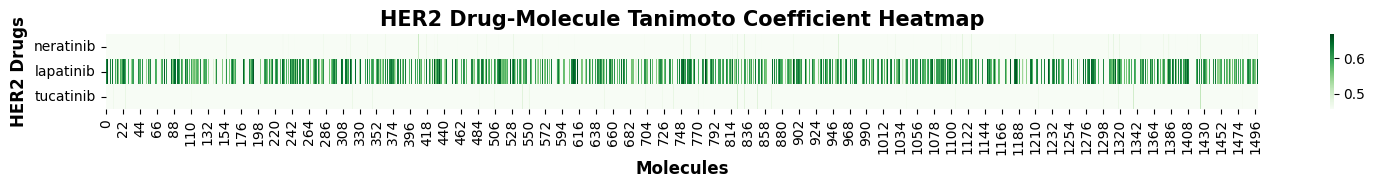

In [42]:
her2_smiles = her2_tm3['f2-4'].smiles.to_list()
her2_drug_dir = {'neratinib':'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=CC(=C(C=C3)OCC4=CC=CC=N4)Cl)C#N)NC(=O)C=CCN(C)C', 
               'lapatinib': 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl', 
               'tucatinib': 'CC1=C(C=CC(=C1)NC2=NC=NC3=C2C=C(C=C3)NC4=NC(CO4)(C)C)OC5=CC6=NC=NN6C=C5'}

her2_drug_name= her2_drug_dir.keys()
her2_drug_dock = {'neratinib': -8.5, 
               'lapatinib': -9.7, 
               'tucatinib': -10.6}


her2_drug_lip = {}
for key, values in her2_drug_dir.items():
    lip_sc = lipinskiness(values)
    her2_drug_lip[key] = lip_sc
print(her2_drug_lip.values())


her2_drugs = [Chem.MolFromSmiles(drug) for drug in her2_drug_dir.values()]
her2_mols = [Chem.MolFromSmiles(smile) for smile in her2_smiles]
her2_mol_fps = []

# Safely calculate fingerprints for the molecules
for mol in her2_mols:
    try:
        if mol is not None:
            fp = MACCSkeys.GenMACCSKeys(mol)
            her2_mol_fps.append(fp)
        else:
            her2_mol_fps.append(0)
    except Exception as e:
        print(f"An error occurred while processing the molecule: {e}")

# Assuming her2_drug_fps has been created already
similarity_matrix = np.zeros((len(her2_drug_fps), len(her2_mol_fps)))

# Calculate similarity scores safely
for i in range(len(her2_drug_fps)):
    for j in range(len(her2_mol_fps)):
        try:
            score = DataStructs.TanimotoSimilarity(her2_drug_fps[i], her2_mol_fps[j])
            similarity_matrix[i, j] = score
        except Exception as e:
            continue


her2_tani_score = []
for i in range(len(her2_mol_fps)):
    score = 0
    for j in range(len(her2_drug_fps)):
        try:
            tani_score = DataStructs.TanimotoSimilarity(her2_drug_fps[j], her2_mol_fps[i])
            if tani_score > score:
                score = tani_score
        except Exception as e:
            print(f"Error calculating Tanimoto score: {e}")
    her2_tani_score.append(score)

her2_tani_score = np.array(her2_tani_score)
print(f"Average Tanimoto score for HER2-targeting molecules: {her2_tani_score.mean()}, \nstd: {her2_tani_score.std():.3f}")
print('max Tanimoto:',her2_tani_score.max())
plt.figure(figsize=(16, 1))
sns.heatmap(similarity_matrix, annot=False, fmt=".2f", cmap='Greens', vmin=0.457, vmax=0.667,
            yticklabels=[f'{key}' for key in her2_drug_dir.keys()])
plt.xlabel('Molecules', fontsize=12, fontweight='bold')
plt.ylabel('HER2 Drugs', fontsize=12, fontweight='bold')
plt.title('HER2 Drug-Molecule Tanimoto Coefficient Heatmap', fontsize=15, fontweight='bold')
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.2)
plt.show()